In [90]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import fastf1
import fastf1.plotting

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from pathlib import Path
import json
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    root_mean_squared_error, 
    mean_absolute_error,
    average_precision_score,
    precision_recall_curve
    )

CACHE_DIR = Path("data/fastf1_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
Path("report/figures").mkdir(parents=True, exist_ok=True)
fastf1.Cache.enable_cache(str(CACHE_DIR))

# Use available device (NVIDIA GPU, M-series GPU, or CPU) for faster computations during training
if torch.cuda.is_available():
    device = torch.device("cuda") # NVIDIA GPU
elif torch.backends.mps.is_available():
    device = torch.device("mps") # Apple Silicon GPU
else:
    device = torch.device("cpu") 
print(device)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

mps


In [91]:
# Load a race
# R = race; Q = Qualifying; S = Sprint; FP1/FP2/FP3 = free practice
session = fastf1.get_session(2024, 'Bahrain', 'R')
session.load()

print(f"Event:      {session.event['EventName']} {session.event.year}")
print(f"Session:    {session.name}")
print(f"Date:       {session.date.date()}")
print(f"Total laps: {session.total_laps}")
print(f"Drivers:    {len(session.drivers)}")

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


Event:      Bahrain Grand Prix 2024
Session:    Race
Date:       2024-03-02
Total laps: 57
Drivers:    20


In [92]:
laps = session.laps
print(f"Shape: {laps.shape}")
print(f"\nAll columns ({len(laps.columns)}):")
print(laps.columns.tolist())

Shape: (1129, 31)

All columns (31):
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


In [93]:
laps[['Driver', 'LapNumber', 'LapTime', 'Compound', 'TyreLife', 'Stint', 'Position', 'TrackStatus']].head(10)

,Driver,LapNumber,LapTime,Compound,TyreLife,Stint,Position,TrackStatus
0,VER,1.0,0 days 00:01:37.284000,SOFT,4.0,1.0,1.0,12
1,VER,2.0,0 days 00:01:36.296000,SOFT,5.0,1.0,1.0,1
2,VER,3.0,0 days 00:01:36.753000,SOFT,6.0,1.0,1.0,1
3,VER,4.0,0 days 00:01:36.647000,SOFT,7.0,1.0,1.0,1
4,VER,5.0,0 days 00:01:37.173000,SOFT,8.0,1.0,1.0,1
5,VER,6.0,0 days 00:01:37.092000,SOFT,9.0,1.0,1.0,1
6,VER,7.0,0 days 00:01:37.038000,SOFT,10.0,1.0,1.0,1
7,VER,8.0,0 days 00:01:37.024000,SOFT,11.0,1.0,1.0,1
8,VER,9.0,0 days 00:01:37.229000,SOFT,12.0,1.0,1.0,1
9,VER,10.0,0 days 00:01:36.960000,SOFT,13.0,1.0,1.0,12


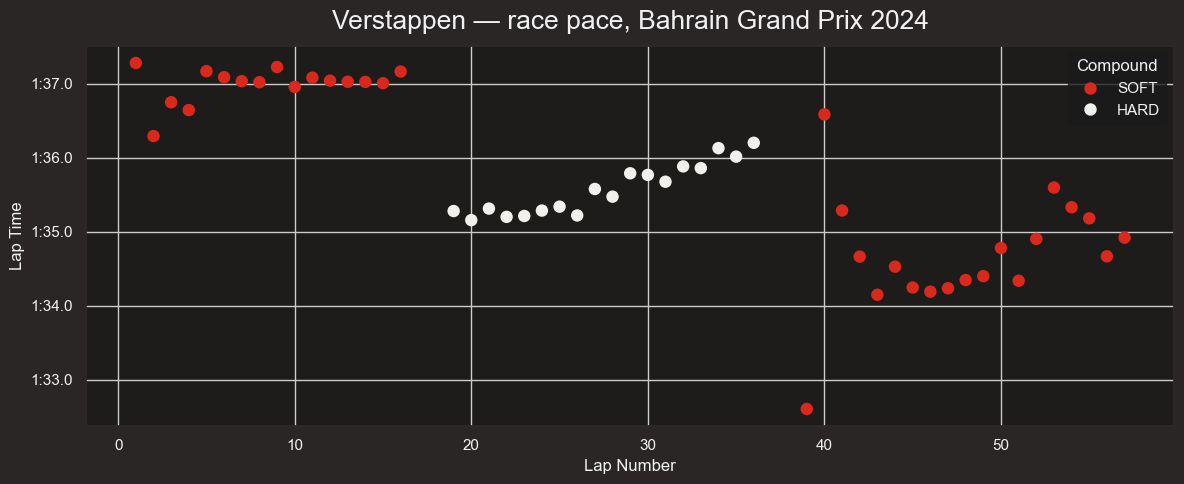

In [94]:
# fastF1's matplotlib setup
fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme='fastf1')

# Lets plot Verstappens laps filtering so only race-pace laps are plotted
ver_laps = session.laps.pick_drivers("VER").pick_quicklaps().reset_index()

fig, ax = plt.subplots(figsize=(12,5))
sns.scatterplot(data=ver_laps,
    x='LapNumber', y="LapTime",
    hue="Compound",
    palette=fastf1.plotting.get_compound_mapping(session=session),
    s=80, linewidth=0, ax=ax,)
ax.invert_yaxis() # faster laps will be towards bottom of y-axis
ax.set_title(f"Verstappen — race pace, {session.event['EventName']} {session.event.year}")
ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time")
plt.tight_layout()
plt.savefig('report/figures/verstappen_pace_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


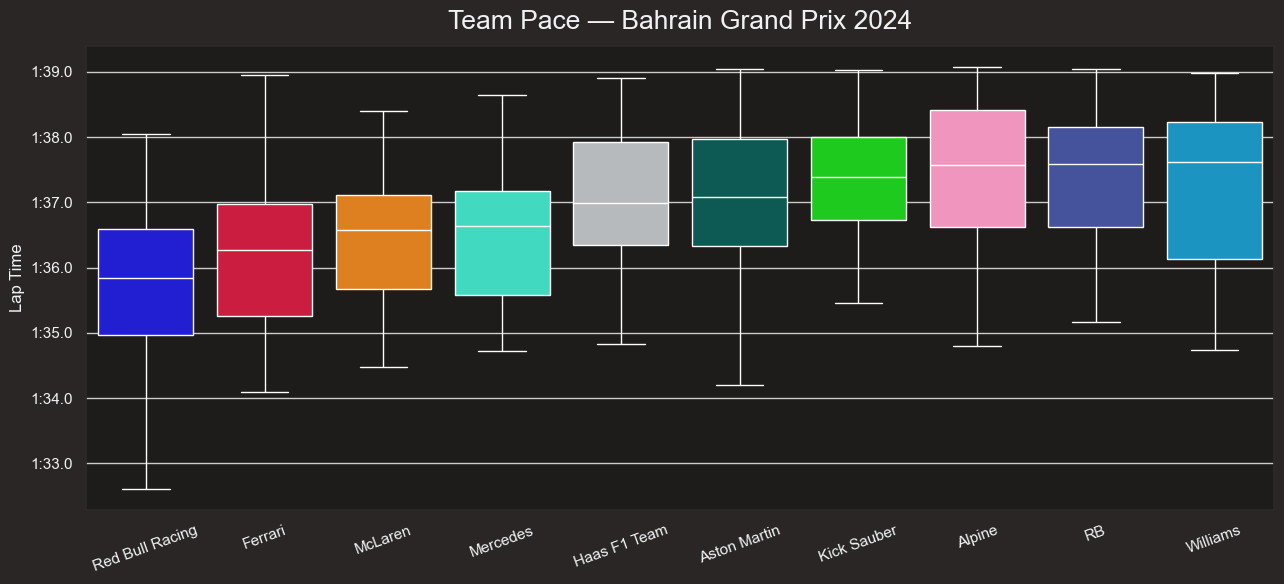

In [95]:
# all race-pace laps across the field
laps_quick = session.laps.pick_quicklaps().copy()


# Sort teams by median pace
team_order = (laps_quick.groupby("Team")["LapTime"].median().sort_values().index.tolist())

team_palette = {team: fastf1.plotting.get_team_color(team, session=session) for team in team_order}

fig, ax = plt.subplots(figsize=(13,6))
sns.boxplot(data=laps_quick,
            x='Team', y='LapTime',
            hue="Team", order=team_order, palette=team_palette,
            legend=False, whiskerprops=dict(color="white"),
            boxprops=dict(edgecolor="white"), medianprops=dict(color="white"),
            capprops=dict(color='white'),
            flierprops=dict(marker='o', markerfacecolor='white', markersize=4, markeredgecolor="none"),)
ax.set_title(f"Team Pace — {session.event['EventName']} {session.event.year}")
ax.set_xlabel("")
ax.set_ylabel("Lap Time")
ax.invert_yaxis()
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('report/figures/team_pace_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

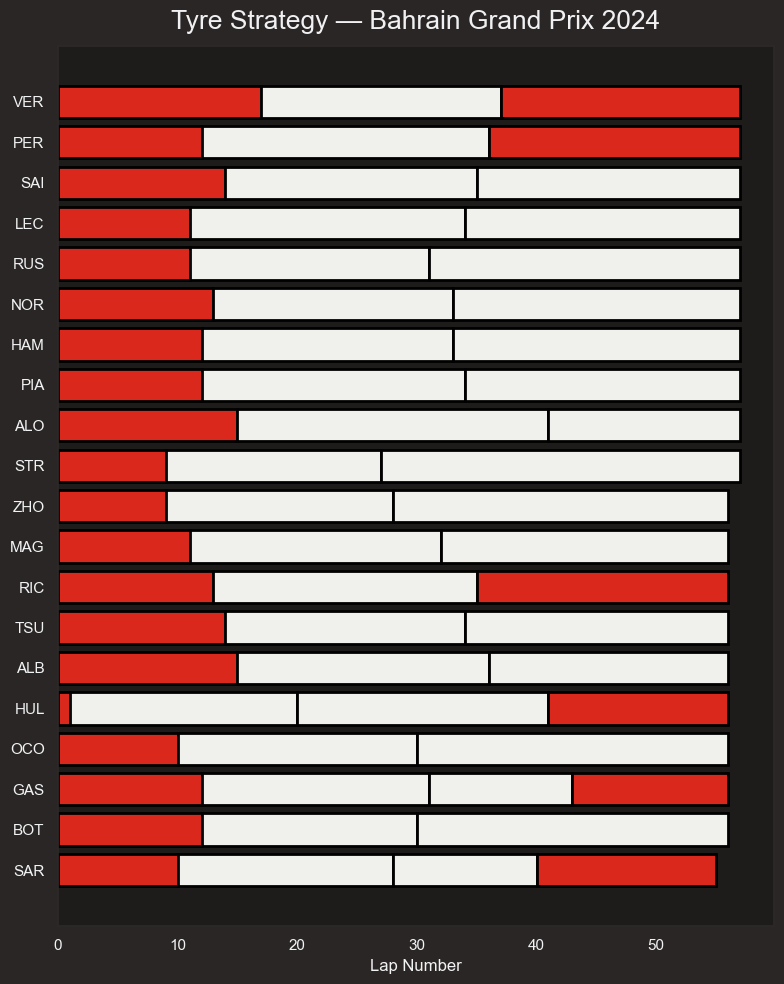

In [96]:
laps = session.laps # all laps, not just race-pace
drivers = session.drivers # driver mumbers in finishing order
driver_codes = [session.get_driver(d)["Abbreviation"] for d in drivers]

# Stints (Driver, Stint, Compound) with stint length (num laps)
stints = (laps[['Driver', 'Stint', 'Compound', 'LapNumber']]
          .groupby(['Driver', 'Stint', 'Compound']).count().reset_index()
          .rename(columns={'LapNumber': 'StintLength'}))

fig, ax = plt.subplots(figsize=(8,10))
for driver in driver_codes:
    driver_stints = stints[stints['Driver'] == driver].sort_values("Stint")
    previous_stint_end = 0
    for _, row in driver_stints.iterrows():
        compound_color = fastf1.plotting.get_compound_color(row['Compound'], session=session)
        ax.barh(y=driver, width=row['StintLength'],
                left=previous_stint_end,
                color=compound_color,
                edgecolor='black',
                linewidth=2,)
        previous_stint_end += row['StintLength']

ax.set_title(f"Tyre Strategy — {session.event['EventName']} {session.event.year}")
ax.set_xlabel("Lap Number")
ax.invert_yaxis() # Winner at top
ax.grid(False)
plt.tight_layout()
plt.savefig('report/figures/tyre_strategy.png', dpi=150, bbox_inches='tight')
plt.show()

In [97]:
def get_completed_races(year):
    '''Return list of (year, round_number, event_name) for races that have occurred'''
    schedule = fastf1.get_event_schedule(year, include_testing=False)
    today = pd.Timestamp.now()
    races = []
    for _, row in schedule.iterrows():
        event_date = pd.Timestamp(row["EventDate"])
        if event_date.tzinfo is not None:
            event_date = event_date.tz_localize(None)
        if event_date <= today:
            races.append((year, int(row['RoundNumber']), row['EventName']))
    return races

def load_race_laps(year, round_num, event_name):
    '''Return a per-lap data frame'''
    session = fastf1.get_session(year, round_num, 'R')
    session.load(telemetry=False, messages=False) # Load laps, weather

    cols = ['Driver','DriverNumber', 'Team',
            'LapNumber', 'LapTime', 'Stint',
            'Compound', 'TyreLife', 'FreshTyre',
            'Position', 'TrackStatus', 'IsAccurate',
            'PitInTime', 'PitOutTime']
    laps = session.laps[cols].copy()

    # weather per lap
    weather = session.laps.get_weather_data().reset_index(drop=True)
    for col in ['AirTemp', 'TrackTemp', 'Humidity', 'Pressure', 'Rainfall', 'WindSpeed', 'WindDirection']:
        if col in weather.columns:
            laps[col] = weather[col].values
    
    # Timedelta -> numeric
    laps['LapTime_s'] = laps['LapTime'].dt.total_seconds()
    laps['IsPitInLap']  = laps['PitInTime'].notna()   # True on the lap where driver pitted
    laps['IsPitOutLap'] = laps['PitOutTime'].notna()  # True on the lap right after pitting

    laps['Year'] = year
    laps['Round'] = round_num
    laps['Event'] = event_name

    laps = laps.drop(columns=['LapTime', 'PitInTime', 'PitOutTime']) # doesn't convert cleanly into CSV
    return laps

def build_dataset(years=(2024,2025,2026), output_path='data/processed/laps.csv', refresh_flag=False):
    '''Load lap data from CSV if it exists; or download from FastF1 and save as CSV. Return data'''

    output_path = Path(output_path)

    # load the saved CSV
    if output_path.exists() and not refresh_flag:
        print(f'Loading cached dataset from {output_path}')
        full = pd.read_csv(output_path)
        n_races = full.groupby(['Year', 'Round']).ngroups
        print(f'Loaded {len(full):,} lap rows from {n_races} races')
        return full
    
    output_path.parent.mkdir(parents=True, exist_ok=True) # create data/processed/
    all_laps = []
    for year in years:
        races = get_completed_races(year)
        print(f'{year}: {len(races)} completed races')
        for y, r, name in races:
            # In case of error while downloading
            try:
                df = load_race_laps(y,r,name)
                all_laps.append(df)
                print(f'\tRound {r:2d}: {name:35s} -> {len(df):4d} laps')
            except Exception  as e:
                print(f'\tRound {r:2d}: {name:35s} -> FAILED ({type(e).__name__}: {e})')
    full = pd.concat(all_laps, ignore_index=True)
    full.to_csv(output_path, index=False)
    print(f'Saved {len(full):,} lap rows from {len(all_laps)} races to {output_path}')
    return full

In [98]:
laps_all = build_dataset(years=(2024, 2025, 2026))
laps_all.head()

Loading cached dataset from data/processed/laps.csv
Loaded 57,366 lap rows from 52 races


,Driver,DriverNumber,Team,LapNumber,Stint,Compound,TyreLife,FreshTyre,Position,TrackStatus,IsAccurate,AirTemp,TrackTemp,Humidity,Pressure,Rainfall,WindSpeed,WindDirection,LapTime_s,IsPitInLap,IsPitOutLap,Year,Round,Event
0,VER,1,Red Bull Racing,1.0,1.0,SOFT,4.0,False,1.0,12,False,18.2,23.8,49.0,1017.2,False,1.5,58,97.284,False,False,2024,1,Bahrain Grand Prix
1,VER,1,Red Bull Racing,2.0,1.0,SOFT,5.0,False,1.0,1,True,18.3,23.8,49.0,1017.0,False,1.1,33,96.296,False,False,2024,1,Bahrain Grand Prix
2,VER,1,Red Bull Racing,3.0,1.0,SOFT,6.0,False,1.0,1,True,18.3,23.8,49.0,1017.1,False,1.5,89,96.753,False,False,2024,1,Bahrain Grand Prix
3,VER,1,Red Bull Racing,4.0,1.0,SOFT,7.0,False,1.0,1,True,18.3,23.7,49.0,1017.0,False,0.9,24,96.647,False,False,2024,1,Bahrain Grand Prix
4,VER,1,Red Bull Racing,5.0,1.0,SOFT,8.0,False,1.0,1,True,18.3,23.5,50.0,1017.1,False,1.5,40,97.173,False,False,2024,1,Bahrain Grand Prix


In [99]:
# change RB team name to be Racing Bulls as it just was renamed for 2025-2026
laps_all['Team'] = laps_all['Team'].replace({'RB': 'Racing Bulls'})

# Use only the teams that were active from 2024-2026
continuous_teams = ['Red Bull Racing', 'Ferrari', 'McLaren', 'Mercedes',
                    'Williams', 'Haas F1 Team', 'Aston Martin', 'Alpine',
                    'Racing Bulls']
before = len(laps_all)
laps_all = laps_all[laps_all['Team'].isin(continuous_teams)].copy()
print(f'Dropped {before - len(laps_all):,} rows from non-continuous teams')
print(f'Remaining: {len(laps_all):,} rows across {laps_all["Team"].nunique()} teams')
print(f'\nRaces by year (after filter): {dict(laps_all.groupby("Year")["Round"].nunique())}')

Dropped 5,904 rows from non-continuous teams
Remaining: 51,462 rows across 9 teams

Races by year (after filter): {2024: np.int64(24), 2025: np.int64(24), 2026: np.int64(4)}


In [100]:
# Mask for clean race pace laps
clean_mask = ((laps_all['IsAccurate'] == True)
              & (~laps_all['IsPitInLap'])
              & (~laps_all['IsPitOutLap'])
              & (laps_all['TrackStatus'].astype(str) == '1')  # green flag
              & (laps_all['LapTime_s'].notna()))
clean_laps = laps_all[clean_mask]

# race median lap time
race_medians = (clean_laps.groupby(['Year', 'Round'])['LapTime_s'].median().rename('RaceMedian_s').reset_index())

# Merge back to the FULL dataset (including pit/SC laps — those become large positive deltas)
laps_all = laps_all.merge(race_medians, on=['Year', 'Round'], how='left')
laps_all['LapTimeDelta_s'] = laps_all['LapTime_s'] - laps_all['RaceMedian_s']

print(f'Race medians computed: {len(race_medians)} races')
print(f'\nDelta distribution stats:')
print(laps_all['LapTimeDelta_s'].describe())

Race medians computed: 52 races

Delta distribution stats:
count    50900.000000
mean         3.306408
std         40.898381
min        -13.643000
25%         -0.759125
50%          0.228000
75%          1.386000
max       2437.577000
Name: LapTimeDelta_s, dtype: float64


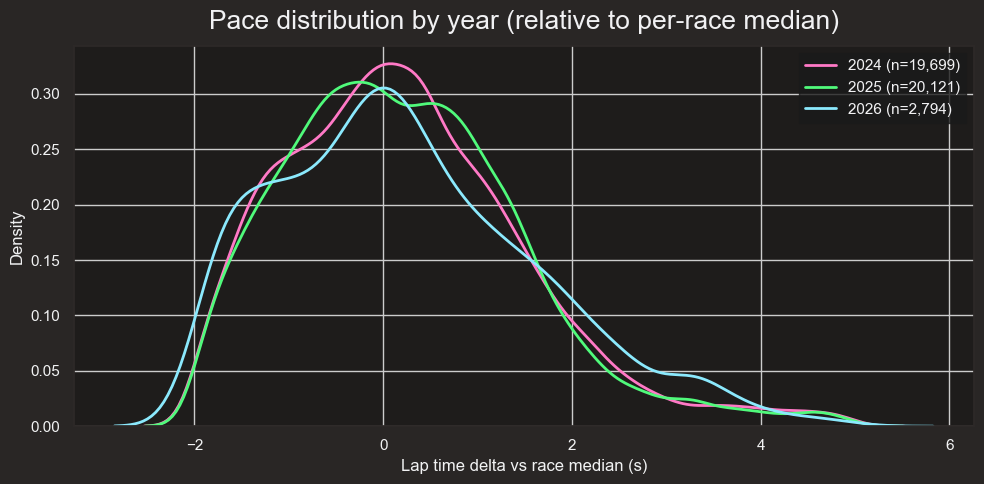

In [101]:
fig, ax = plt.subplots(figsize=(10, 5))
for year in sorted(laps_all['Year'].unique()):
    yr = laps_all[(laps_all['Year'] == year) &
                  (laps_all['LapTimeDelta_s'].between(-2, 5))]  # zoom into reasonable pace
    sns.kdeplot(yr['LapTimeDelta_s'], label=f'{year} (n={len(yr):,})',
                ax=ax, linewidth=2)
ax.set_xlabel('Lap time delta vs race median (s)')
ax.set_ylabel('Density')
ax.set_title('Pace distribution by year (relative to per-race median)')
ax.legend()
plt.tight_layout()
plt.savefig('report/figures/pace_distribution_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

In [102]:
# drop rows with no delta
before = len(laps_all)
laps_all = laps_all.dropna(subset=['LapTimeDelta_s']).copy()
print(f'Dropped {before - len(laps_all)} rows with NaN delta')

# drop outliers for +/- 60s against the median as these are red flags, time was not stopped correctly, etc.
# But still keep slow laps which are pits
outliers = (laps_all['LapTimeDelta_s'].abs() > 60)
laps_all = laps_all[~outliers].copy()
print(f'Dropping {outliers.sum()} extreme outlier laps (|delta| > 60s)')

print(f'Final dataset: {len(laps_all):,} rows')
print(f'Deltas after cleaning: {laps_all['LapTimeDelta_s'].describe()}')

Dropped 562 rows with NaN delta
Dropping 70 extreme outlier laps (|delta| > 60s)
Final dataset: 50,830 rows
Deltas after cleaning: count    50830.000000
mean         2.566052
std          8.802917
min        -13.643000
25%         -0.761000
50%          0.226000
75%          1.381000
max         59.825500
Name: LapTimeDelta_s, dtype: float64


In [103]:
laps_all = laps_all.sort_values(['Year','Round','Driver','LapNumber']).reset_index(drop=True)

n_races = laps_all.groupby(['Year','Round']).ngroups
n_sequences = laps_all.groupby(['Year', 'Round', 'Driver']).ngroups
avg_laps = len(laps_all)/n_sequences
print(f'Rows: {len(laps_all):,}')
print(f'Unique races: {n_races}')
print(f'Unique (race, driver): {n_sequences:,}')
print(f'Avg laps per sequence: {avg_laps:1f}')

Rows: 50,830
Unique races: 52
Unique (race, driver): 903
Avg laps per sequence: 56.290144


In [104]:
# one row per race
race_keys = laps_all[['Year','Round']].drop_duplicates().reset_index(drop=True)

# 75% train, 25% test
train_races, test_races = train_test_split(race_keys, test_size=0.25,
                                        random_state=SEED, shuffle=True)

train_laps = laps_all.merge(train_races, on=['Year', 'Round'], how='inner')
test_laps  = laps_all.merge(test_races,  on=['Year', 'Round'], how='inner')

print(f'Total races: {len(race_keys)}')
print(f'  Train: {len(train_races)} races, {len(train_laps):,} lap rows')
print(f'  Test:  {len(test_races)} races, {len(test_laps):,} lap rows')

print(f'\nRaces per split, by year:')
print(pd.concat([
    train_races.assign(Split='train'),
    test_races.assign(Split='test'),
]).groupby(['Split', 'Year']).size().unstack(fill_value=0))


Total races: 52
  Train: 39 races, 37,557 lap rows
  Test:  13 races, 13,273 lap rows

Races per split, by year:
Year   2024  2025  2026
Split                  
test      7     5     1
train    17    19     3


In [105]:
NUMERICS = ['LapTimeDelta_s', 'TyreLife', 'Position', 'Stint',
                'AirTemp', 'TrackTemp', 'Humidity', 'WindSpeed']

BOOLS = ['IsPitInLap', 'IsPitOutLap', 'FreshTyre', 'Rainfall']

COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']

def encode_features(df):
    '''Convert into tensor compatibile floats'''
    df = df.copy()

    # one-hot encodings
    df['Compound'] = pd.Categorical(df['Compound'], categories=COMPOUNDS)
    compounds_1hot = pd.get_dummies(df['Compound'], prefix='Comp', dtype=float)
    team_1hot = pd.get_dummies(df['Team'], prefix='Team', dtype=float)
    year_1hot = pd.get_dummies(df['Year'], prefix='Year', dtype=float)

    # bools to floats
    for col in BOOLS:
        df[col] = df[col].astype(float)
        
    out = pd.concat([df[['Year','Round','Driver','LapNumber']],
                    df[NUMERICS], df[BOOLS], compounds_1hot, 
                    team_1hot, year_1hot], axis=1)
    return out

train_features = encode_features(train_laps)
test_features = encode_features(test_laps)


all_cols = sorted(set(train_features.columns) | set(test_features.columns)) # identical features for train and test
for c in all_cols:
    if c not in train_features: train_features[c] = 0.0
    if c not in test_features: test_features[c] = 0.0

train_features = train_features[all_cols]
test_features = test_features[all_cols]

print(f'Encoded features: {len(all_cols)} columns')
print(f'  Train: {train_features.shape}')
print(f'  Test:  {test_features.shape}')
print(f'\nColumn list:')
print(all_cols)

Encoded features: 33 columns
  Train: (37557, 33)
  Test:  (13273, 33)

Column list:
['AirTemp', 'Comp_HARD', 'Comp_INTERMEDIATE', 'Comp_MEDIUM', 'Comp_SOFT', 'Comp_WET', 'Driver', 'FreshTyre', 'Humidity', 'IsPitInLap', 'IsPitOutLap', 'LapNumber', 'LapTimeDelta_s', 'Position', 'Rainfall', 'Round', 'Stint', 'Team_Alpine', 'Team_Aston Martin', 'Team_Ferrari', 'Team_Haas F1 Team', 'Team_McLaren', 'Team_Mercedes', 'Team_Racing Bulls', 'Team_Red Bull Racing', 'Team_Williams', 'TrackTemp', 'TyreLife', 'WindSpeed', 'Year', 'Year_2024', 'Year_2025', 'Year_2026']


In [106]:
# Normalize 
NORM_COLS = ['TyreLife','Position','Stint','AirTemp','TrackTemp','Humidity','WindSpeed']

train_mean = train_features[NORM_COLS].mean()
train_std = train_features[NORM_COLS].std()

train_features[NORM_COLS] = (train_features[NORM_COLS]- train_mean) / train_std
test_features[NORM_COLS] = (test_features[NORM_COLS]- train_mean) / train_std

train_features = train_features.fillna(0)
test_features = test_features.fillna(0)

print(pd.DataFrame({'mean': train_mean, 'std': train_std}).round(3))
print('Train features normalized:')
print(train_features[NORM_COLS].describe().round(3))

             mean     std
TyreLife   15.352  11.188
Position    9.183   5.285
Stint       1.974   0.889
AirTemp    23.136   4.580
TrackTemp  34.454   9.387
Humidity   52.619  16.316
WindSpeed   1.777   1.043
Train features normalized:
        TyreLife   Position      Stint    AirTemp  TrackTemp   Humidity  WindSpeed
count  37557.000  37557.000  37557.000  37557.000  37557.000  37557.000  37557.000
mean      -0.000      0.000      0.000      0.000     -0.000      0.000     -0.000
std        0.995      1.000      0.996      1.000      1.000      1.000      1.000
min       -1.283     -1.549     -1.095     -1.886     -1.891     -2.183     -1.704
25%       -0.747     -0.792     -1.095     -0.881     -0.783     -0.835     -0.745
50%       -0.210     -0.035      0.030     -0.095     -0.230      0.146     -0.266
75%        0.505      0.722      0.030      0.800      0.878      0.759      0.501
max        5.600      2.047      5.653      2.350      1.794      2.414      4.240


In [107]:
pitinlaps = train_features['IsPitInLap'].sum()

print(f'Number of pit in laps: {pitinlaps}')
print(f'Number of total laps: {len(train_features)}')
print(f'Percentage of pit in laps: {pitinlaps/len(train_features)*100}')

Number of pit in laps: 1104.0
Number of total laps: 37557
Percentage of pit in laps: 2.9395319114945284


In [108]:
class LapWindowDataset(Dataset):
    '''Sliding-window dataset for per-(race, driver) lap sequences.
    Each item is tuple (X,y) where:
        X = tensor of shape (lookback, n_features) - past lookback laps features
        y = tensor of shape (horizon,) - next horizon LapTimeDelta_s targets
        Widows extracted within a single (Year, Round, Driver) sequence and never span
        across races or drivers'''
    
    KEY_COLS = ['Year', 'Round', 'Driver', 'LapNumber']
    TARGET = 'LapTimeDelta_s'
    PIT_TARGET = 'IsPitInLap'

    def __init__(self, features_df, lookback=10, horizon=5):
        self.lookback = lookback
        self.horizon = horizon
        self.feature_cols = [c for c in features_df.columns if c not in self.KEY_COLS]
        self.n_features = len(self.feature_cols)

        # Build windows
        all_X, all_y, all_y_pit = [], [], []
        for _, group in features_df.groupby(['Year', 'Round', 'Driver'], sort=False):
            group = group.sort_values('LapNumber') # chronological lap order
            n = len(group)
            if n < lookback + horizon:
                continue # too small a sequence to make a window
            features = group[self.feature_cols].to_numpy(dtype=np.float32)
            targets = group[self.TARGET].to_numpy(dtype=np.float32)
            target_pit = group[self.PIT_TARGET].to_numpy(dtype=np.float32)
            # slide the window forward one lap at a time
            for s in range(n - lookback - horizon + 1):
                all_X.append(features[s : s + lookback]) #(lookback, n_features)
                all_y.append(targets[s + lookback : s + lookback + horizon]) # (horizon,)
                all_y_pit.append(target_pit[s + lookback : s + lookback + horizon])
            
        self.X = np.stack(all_X) if all_X else np.empty((0, lookback, self.n_features), dtype=np.float32)
        self.y = np.stack(all_y) if all_y else np.empty((0, horizon), dtype=np.float32)
        self.y_pit = np.stack(all_y_pit) if all_y_pit else np.empty((0, horizon), dtype=np.float32)
    
    def __len__(self):
        # Total windows
        return len(self.X)
    
    def __getitem__(self, index):
        # numpy -> torch 
        return (torch.from_numpy(self.X[index]),    # (lookback, n_features)
                torch.from_numpy(self.y[index]),     # (horizon,)
                torch.from_numpy(self.y_pit[index]))     # (horizon,)
    
# 10 past laps in, 5 future laps out
LOOKBACK, HORIZON = 10, 5

train_ds = LapWindowDataset(train_features, lookback=LOOKBACK, horizon=HORIZON)
test_ds = LapWindowDataset(test_features, lookback=LOOKBACK, horizon=HORIZON)

# check windows
print(f'Train windows: {len(train_ds):,}')
print(f'Test windows:  {len(test_ds):,}')
print(f'Feature dim:   {train_ds.n_features}')
print(f'Sample X shape: {train_ds[0][0].shape}, y shape: {train_ds[0][1].shape}')
print(f'y_pit: {train_ds.y_pit}')
print(f'y_pit base rate: {train_ds.y_pit.mean():.4f}')        # expect ~0.029
print(f'Windows with >=1 pit: {(train_ds.y_pit.sum(axis=1) > 0).sum()} / {len(train_ds)}')
print(f'% of Windows with >=1 pit: {(train_ds.y_pit.sum(axis=1) > 0).sum() / len(train_ds) * 100}')


Train windows: 28,254
Test windows:  10,076
Feature dim:   29
Sample X shape: torch.Size([10, 29]), y shape: torch.Size([5])
y_pit: [[0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 ...
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
y_pit base rate: 0.0299
Windows with >=1 pit: 4040 / 28254
% of Windows with >=1 pit: 14.298860338359171


In [109]:
# Mini batch Gradient Descent
BATCH_SIZE = 128

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# check a batch
xb, yb_delta, yb_pit = next(iter(train_loader))
print(f'Batch X: {xb.shape}, dtype={xb.dtype}')   # (BATCH_SIZE, LOOKBACK, n_features)
print(f'Batch y_delta: {yb_delta.shape}')     # (128, 5)
print(f'Batch y_pit:   {yb_pit.shape}')       # (128, 5)
print(f'Pit positives in this batch: {int(yb_pit.sum())} / {yb_pit.numel()}')
print(f'\nFirst sample target (next 5 lap deltas, in seconds):')
print(yb_delta[0].numpy().round(3))
print(f'\nFeature stats (over the batch):')
print(f'  mean: {xb.mean():.4f}')
print(f'  std:  {xb.std():.4f}')
print(f'  min:  {xb.min():.4f}')
print(f'  max:  {xb.max():.4f}')


Batch X: torch.Size([128, 10, 29]), dtype=torch.float32
Batch y_delta: torch.Size([128, 5])
Batch y_pit:   torch.Size([128, 5])
Pit positives in this batch: 12 / 640

First sample target (next 5 lap deltas, in seconds):
[-0.703 -0.643 -0.893 -0.065 -0.468]

Feature stats (over the batch):
  mean: 0.1991
  std:  1.3448
  min:  -3.3400
  max:  51.9800


In [110]:
def evaluate(model, loader):
    '''Return RMSE in seconds across the loader.'''
    model.eval()
    yhat_all, y_all = [], []

    with torch.no_grad():
        for xb, yb_delta, yb_pit in loader:
            xb = xb.to(device)
            delta_pred, _ = model(xb)
            yhat_all.append(delta_pred.cpu().numpy())
            y_all.append(yb_delta.numpy())

    yhat = np.concatenate(yhat_all).flatten()
    y    = np.concatenate(y_all).flatten()
    return root_mean_squared_error(y, yhat)

def evaluate_pit(model, loader):
    '''Return PR-AUC across the loader.'''
    model.eval()
    yhat_all, y_all = [], []

    with torch.no_grad():
        for xb, yb_delta, yb_pit in loader:
            xb = xb.to(device)
            _, pit_logits = model(xb)
            yhat_all.append(pit_logits.cpu().numpy())
            y_all.append(yb_pit.numpy())

    yhat = np.concatenate(yhat_all).flatten()
    y    = np.concatenate(y_all).flatten()
    return average_precision_score(y, yhat)

def evaluate_losses(model, test_loader, bce_criterion):
    '''Return test MSE and BCE'''
    model.eval()
    mse_criterion = nn.MSELoss()
    running_mse = 0.0
    running_bce = 0.0
    n_batches = 0
    
    with torch.no_grad():
        for xb, yb_delta, yb_pit in test_loader:
            xb, yb_delta, yb_pit = xb.to(device), yb_delta.to(device), yb_pit.to(device)
            delta_pred, pit_logits = model(xb)
            running_mse += mse_criterion(delta_pred, yb_delta).item()
            running_bce += bce_criterion(pit_logits, yb_pit).item()
            n_batches   += 1

    return running_mse / n_batches, running_bce / n_batches 

def tolerance_acc_curve(model, loader, thresholds=np.linspace(0.1,5,50)):
    '''For each tolerance delta, return fraction of test predictions within +/- delta of actual'''
    model.eval()
    yhat_all, y_all = [], []

    with torch.no_grad():
        for xb, yb_delta, yb_pit in loader:
            xb = xb.to(device)
            delta_pred, _ = model(xb)
            yhat_all.append(delta_pred.cpu().numpy())
            y_all.append(yb_delta.numpy())
    yhat = np.concatenate(yhat_all).flatten()
    y = np.concatenate(y_all).flatten()
    abs_err = np.abs(y - yhat)
    return [(abs_err < t).mean() for t in thresholds], thresholds

def get_predictions(model, loader):
    # used for scatter plots
    model.eval()
    yhat_all, y_all = [], []

    with torch.no_grad():
        for xb, yb_delta, yb_pit in loader:
            xb = xb.to(device)
            delta_pred, _ = model(xb)
            yhat_all.append(delta_pred.cpu().numpy())
            y_all.append(yb_delta.numpy())
    yhat = np.concatenate(yhat_all).flatten()
    y = np.concatenate(y_all).flatten()
    return yhat, y

def train_model(model, train_loader, test_loader, epochs=30, lr=1e-3, weight_decay=0.0, 
                pos_weight=33, pit_loss_weight=1.0, model_name='Model', verbose_every=5):
    '''Training loop. Optimizes MSE(delta) + pit_loss_weight * BCE(pit); reports per-epoch.'''
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    # Loss functions
    mse = nn.MSELoss()
    bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight], device=device))
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    hist = {'train_rmse': [], 'test_rmse': [],
            'train_mse': [], 'test_mse': [],
            'train_bce': [], 'test_bce': []}

    for epoch in range(epochs):
        model.train()
        running_loss_delta = 0.0
        running_loss_pit = 0.0
        n_batches   = 0

        for xb, yb_delta, yb_pit in train_loader:
            xb, yb_delta, yb_pit = xb.to(device), yb_delta.to(device), yb_pit.to(device)
            optimizer.zero_grad()

            delta_preds, pit_preds = model(xb)
            loss_delta  = mse(delta_preds, yb_delta)
            loss_pit = bce(pit_preds, yb_pit)
            loss = loss_delta + pit_loss_weight * loss_pit

            loss.backward()
            optimizer.step()

            running_loss_delta += loss_delta.item()
            running_loss_pit += loss_pit.item()
            n_batches   += 1

        train_mse = running_loss_delta / n_batches
        train_rmse = train_mse ** 0.5
        train_bce = running_loss_pit / n_batches
        scheduler.step()
        test_mse, test_bce = evaluate_losses(model, test_loader, bce)
        test_rmse = test_mse ** 0.5

        hist['train_rmse'].append(train_rmse)
        hist['train_mse'].append(train_mse)
        hist['train_bce'].append(train_bce)

        hist['test_rmse'].append(test_rmse)
        hist['test_mse'].append(test_mse)
        hist['test_bce'].append(test_bce)

        if (epoch + 1) % verbose_every == 0 or epoch in (0, epochs - 1):
            print(f'Epoch {epoch+1:3d}/{epochs} — Train RMSE {train_rmse:5.3f}s, BCE {train_bce:5.3f} | Test RMSE {test_rmse:5.3f}s, BCE {test_bce:5.3f}')


    return hist

def save_metrics(model_name, model_obj, hist, hyperparameters, test_loader,
                 results_dir='results'):
    '''Persist a single training-run record to results/{model}_{timestamp}.json.'''
    Path(results_dir).mkdir(parents=True, exist_ok=True)
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    fractions, thresholds = tolerance_acc_curve(model_obj, test_loader)
    pit_pr_auc = evaluate_pit(model_obj, test_loader)
    final_train = hist['train_rmse'][-1]
    final_test  = hist['test_rmse'][-1]
    best_test   = min(hist['test_rmse'])
    best_epoch  = hist['test_rmse'].index(best_test) + 1
    
    record = {
        'model_name': model_name,
        'timestamp': datetime.now().isoformat(timespec='seconds'),
        'hyperparameters': hyperparameters,
        'model_info': {
            'class': type(model_obj).__name__,
            'total_params': sum(p.numel() for p in model_obj.parameters()),
        },
        'history': {
            'train_rmse': [float(x) for x in hist['train_rmse']],
            'test_rmse':  [float(x) for x in hist['test_rmse']],
            'train_mse':  [float(x) for x in hist['train_mse']],
            'test_mse':   [float(x) for x in hist['test_mse']],
            'train_bce':  [float(x) for x in hist['train_bce']],
            'test_bce':   [float(x) for x in hist['test_bce']],
        },
        'summary': {
            'final_train_rmse': float(final_train),
            'final_test_rmse':  float(final_test),
            'best_test_rmse':   float(best_test),
            'best_epoch':       int(best_epoch),
            'gap':              float(final_test - final_train),
            'final_train_bce':       float(hist['train_bce'][-1]),
            'final_test_bce':        float(hist['test_bce'][-1]),
            'best_test_bce':         float(min(hist['test_bce'])),
            'best_test_bce_epoch':   int(hist['test_bce'].index(min(hist['test_bce'])) + 1),
            'final_test_pit_pr_auc': float(pit_pr_auc),
            'pit_base_rate':         0.029,
        },
        'tolerance_accuracy': {
            'tolerances': [float(t) for t in thresholds],
            'fractions':  [float(f) for f in fractions],
        },
    }
    path = Path(results_dir) / f'{model_name}_{timestamp}.json'
    with open(path, 'w') as f:
        json.dump(record, f, indent=2)
    print(f'Metrics saved -> {path}')
    return path


In [111]:
class MLP_model(nn.Module):
    '''Flatten input window into 1 vector -> 2 hidden layers -> 5 predictions
    Uses He/Kaiming initialization'''
    def __init__(self, lookback, n_features, horizon, hidden_dim=64, dropout=0.2):
        super().__init__()

        self.body = nn.Sequential(
            nn.Flatten(), # 10x29 -> 290
            nn.Linear(lookback * n_features, hidden_dim), # 290 -> 64
            nn.ReLU(), # 256
            nn.Dropout(dropout), 
            nn.Linear(hidden_dim, hidden_dim), # 64 -> 64
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.delta_head = nn.Linear(64,5)
        self.pit_head = nn.Linear(64,5)
        self.apply(self._he_init)

    @staticmethod
    def _he_init(module):
        '''Apply He/Kaiming normal init to linear layers'''
        if isinstance(module, nn.Linear):
            nn.init.kaiming_normal_(module.weight, mode='fan_in',nonlinearity='relu')
            if module.bias is not None:
                nn.init.zeros_(module.bias)
    def forward(self, x):
        h = self.body(x)
        return (self.delta_head(h), self.pit_head(h))
    

torch.manual_seed(SEED)
m = MLP_model(LOOKBACK, train_ds.n_features, HORIZON, hidden_dim=64, dropout=0.2)
xb, yb_delta, yb_pit = next(iter(train_loader))
delta, pit = m(xb)
print(delta.shape, pit.shape)   # both should be torch.Size([128, 5])
print(f'Params: {sum(p.numel() for p in m.parameters()):,}')  # ~23,400 — old 23,109 + ~325 for the second head


torch.Size([128, 5]) torch.Size([128, 5])
Params: 23,434


In [ ]:
torch.manual_seed(SEED)
mlp = MLP_model(
    lookback=LOOKBACK,
    n_features=train_ds.n_features,
    horizon=HORIZON,
    hidden_dim=64,
    dropout=0.2
)
n_params = sum(p.numel() for p in mlp.parameters())
print(f'Multilayer Perceptron - {n_params:,} parameters')
print(mlp, '\n')

EPOCHS = 30
POS_WEIGHT = 33
PIT_LOSS_WEIGHT = 1.0

mlp_hist = train_model(mlp, train_loader, test_loader,
                       epochs=EPOCHS, lr=1e-3, weight_decay=1e-3,
                       pos_weight=POS_WEIGHT, pit_loss_weight=PIT_LOSS_WEIGHT,
                       model_name='Multilayer Perceptron')

final_test_rmse = evaluate(mlp, test_loader)
final_train_rmse = mlp_hist['train_rmse'][-1]
final_train_bce = mlp_hist['train_bce'][-1]
final_test_bce = mlp_hist['test_bce'][-1]
print(f'Multilayer Perceptron - Final Train RMSE = {final_train_rmse:.3f}s')
print(f'Multilayer Perceptron - Final Test RMSE = {final_test_rmse:.3f}s')
print(f'Multilayer Perceptron - Final Train BCE = {final_train_bce:.3f}')
print(f'Multilayer Perceptron - Final Test BCE = {final_test_bce:.3f}')


save_metrics(
    model_name='MLP',
    model_obj=mlp,
    hist=mlp_hist,
    hyperparameters={
        'epochs': EPOCHS, 'lr': 1e-3, 'weight_decay': 1e-3,
        'batch_size': BATCH_SIZE, 'lookback': LOOKBACK, 'horizon': HORIZON,
        'hidden_dim': 64, 'dropout': 0.2,
        'optimizer': 'Adam', 'scheduler': 'StepLR(step_size=10, gamma=0.5)',
        'loss': 'MSE(delta) + pit_loss_weight * BCEWithLogits(pit, pos_weight)',
        'pos_weight': POS_WEIGHT, 'pit_loss_weight': PIT_LOSS_WEIGHT,
        'init': 'He/Kaiming',
    },
    test_loader=test_loader,
)


Multilayer Perceptron - 23,434 parameters
MLP_model(
  (body): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=290, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
  )
  (delta_head): Linear(in_features=64, out_features=5, bias=True)
  (pit_head): Linear(in_features=64, out_features=5, bias=True)
) 

Epoch   1/30 — Train RMSE 7.640s, BCE 1.426 | Test RMSE 7.428s, BCE 1.273
Epoch   5/30 — Train RMSE 6.869s, BCE 1.071 | Test RMSE 7.391s, BCE 1.310
Epoch  10/30 — Train RMSE 6.355s, BCE 0.961 | Test RMSE 7.509s, BCE 1.441
Epoch  15/30 — Train RMSE 6.115s, BCE 0.896 | Test RMSE 7.544s, BCE 1.451
Epoch  20/30 — Train RMSE 5.951s, BCE 0.861 | Test RMSE 7.499s, BCE 1.593
Epoch  25/30 — Train RMSE 5.838s, BCE 0.846 | Test RMSE 7.503s, BCE 1.639
Epoch  30/30 — Train RMSE 5.829s, BCE 0.829 | Test RMSE 7.542s, BCE 1.

PosixPath('results/MLP_20260512_222138.json')

In [113]:
class LSTM_Model(nn.Module):
    '''Ecnodes past 10 laps via input/forget/output gates + cell state then feed into linear layer that predicts next 5 lap deltas
    Init: Glorot/Xavier'''
    def __init__(self, n_features, horizon, hidden_dim=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_dim, num_layers=num_layers, 
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.delta_head = nn.Linear(hidden_dim, horizon)
        self.pit_head = nn.Linear(hidden_dim, horizon)
        self.apply(self._init_weights)
    
    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LSTM):        
            for name, param in module.named_parameters():
                if 'weight' in name:
                    nn.init.xavier_uniform_(param)
                elif 'bias' in name:
                    nn.init.zeros_(param)
    
    def forward(self, x):
        # x = (batch, lookback=10, n_features=29)
        # h_n: (num_layers, batch, hidden_dim) - final hidden
        # c_n:(num_layers, batch, hidden_dim) - final cell  
        _, (h_n, c_n) = self.lstm(x)
        h_last = h_n[-1]
        h_last = self.dropout(h_last) # final hiden 
        return (self.delta_head(h_last), self.pit_head(h_last))  #(batch, horizon=5)

In [ ]:
torch.manual_seed(SEED)
lstm = LSTM_Model(n_features=train_ds.n_features, horizon=HORIZON, hidden_dim=128, num_layers=1)
n_params = sum(p.numel() for p in lstm.parameters())
print(f'LSTM - {n_params:,} parameters')
print(lstm, '\n')

EPOCHS = 30
POS_WEIGHT = 33
PIT_LOSS_WEIGHT = 1.0

lstm_hist = train_model(lstm, train_loader, test_loader,
                        epochs=EPOCHS, lr=1e-3, weight_decay=1e-3,
                        pos_weight=POS_WEIGHT, pit_loss_weight=PIT_LOSS_WEIGHT,
                        model_name='Long Short-Term Memory')

final_test_rmse = evaluate(lstm, test_loader)
final_train_rmse = lstm_hist['train_rmse'][-1]
final_train_bce = lstm_hist['train_bce'][-1]
final_test_bce = lstm_hist['test_bce'][-1]
print(f'Long Short-Term Memory - Final Train RMSE = {final_train_rmse:.3f}s')
print(f'Long Short-Term Memory - Final Test RMSE = {final_test_rmse:.3f}s')
print(f'Long Short-Term Memory - Final Train BCE = {final_train_bce:.3f}')
print(f'Long Short-Term Memory - Final Test BCE = {final_test_bce:.3f}')


save_metrics(
    model_name='LSTM',
    model_obj=lstm,
    hist=lstm_hist,
    hyperparameters={
        'epochs': EPOCHS, 'lr': 1e-3, 'weight_decay': 1e-3,
        'batch_size': BATCH_SIZE, 'lookback': LOOKBACK, 'horizon': HORIZON,
        'hidden_dim': 128, 'num_layers': 1, 'dropout': 0.2,
        'optimizer': 'Adam', 'scheduler': 'StepLR(step_size=10, gamma=0.5)',
        'loss': 'MSE(delta) + pit_loss_weight * BCEWithLogits(pit, pos_weight)',
        'pos_weight': POS_WEIGHT, 'pit_loss_weight': PIT_LOSS_WEIGHT,
        'init': 'Xavier/Glorot',
    },
    test_loader=test_loader,
)


LSTM - 82,698 parameters
LSTM_Model(
  (lstm): LSTM(29, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (delta_head): Linear(in_features=128, out_features=5, bias=True)
  (pit_head): Linear(in_features=128, out_features=5, bias=True)
) 

Epoch   1/30 — Train RMSE 7.466s, BCE 1.201 | Test RMSE 7.385s, BCE 1.256
Epoch   5/30 — Train RMSE 5.774s, BCE 0.853 | Test RMSE 8.027s, BCE 1.512
Epoch  10/30 — Train RMSE 4.974s, BCE 0.647 | Test RMSE 8.238s, BCE 2.011
Epoch  15/30 — Train RMSE 4.603s, BCE 0.519 | Test RMSE 8.738s, BCE 2.741
Epoch  20/30 — Train RMSE 4.407s, BCE 0.461 | Test RMSE 8.392s, BCE 3.292
Epoch  25/30 — Train RMSE 4.249s, BCE 0.396 | Test RMSE 8.709s, BCE 3.837
Epoch  30/30 — Train RMSE 4.159s, BCE 0.370 | Test RMSE 8.671s, BCE 4.258
Long Short-Term Memory - Final Train RMSE = 4.159s
Long Short-Term Memory - Final Test RMSE = 8.624s
Long Short-Term Memory - Final Train BCE = 0.370
Long Short-Term Memory - Final Test BCE = 4.258
Metrics saved -> results/L

PosixPath('results/LSTM_20260512_222208.json')

In [115]:
def model_summary(hist, params, name, model_obj=None, test_loader=None):
    train_final = hist['train_rmse'][-1]
    test_final = hist['test_rmse'][-1]
    test_best = min(hist['test_rmse'])
    best_epoch = hist['test_rmse'].index(test_best) + 1
    train_bce_final = hist['train_bce'][-1]
    test_bce_final = hist['test_bce'][-1]
    pit_pr_auc = evaluate_pit(model_obj, test_loader) if (model_obj is not None and test_loader is not None) else float('nan')
    return {'Model': name,
            'Parameters': params,
            'Train RMSE (s)': round(train_final, 3),
            'Test RMSE (s)': round(test_final, 3),
            'Best Test RMSE (s)': round(test_best, 3),
            'Best Epoch': best_epoch,
            'Gap (s)': round(test_final - train_final, 3),
            'Train BCE': round(train_bce_final, 3),
            'Test BCE': round(test_bce_final, 3),
            'Pit PR-AUC': round(pit_pr_auc, 3),}


n_params_mlp = sum(p.numel() for p in mlp.parameters())
n_params_lstm = sum(p.numel() for p in lstm.parameters())

comp = pd.DataFrame([
    model_summary(mlp_hist, n_params_mlp, 'MLP', mlp, test_loader),
    model_summary(lstm_hist, n_params_lstm, 'LSTM', lstm, test_loader),
])

print(comp.to_string(index=False))
print(f'\nPit base rate (random PR-AUC baseline): 0.029')


Model  Parameters  Train RMSE (s)  Test RMSE (s)  Best Test RMSE (s)  Best Epoch  Gap (s)  Train BCE  Test BCE  Pit PR-AUC
  MLP       23434           5.829          7.542               7.325           3    1.713      0.829     1.691       0.072
 LSTM       82698           4.159          8.671               7.365           2    4.512      0.370     4.258       0.059

Pit base rate (random PR-AUC baseline): 0.029


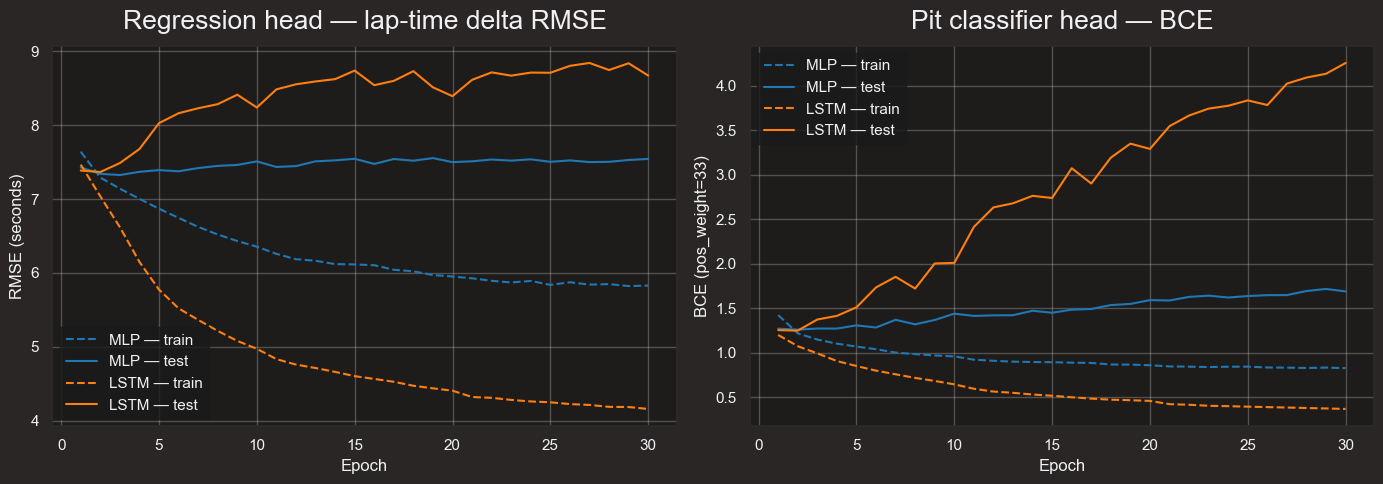

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(mlp_hist['train_rmse']) + 1)

# Left panel: regression head (RMSE)
ax = axes[0]
ax.plot(epochs_range, mlp_hist['train_rmse'],  label='MLP — train',  color='tab:blue',   linestyle='--')
ax.plot(epochs_range, mlp_hist['test_rmse'],   label='MLP — test',   color='tab:blue')
ax.plot(epochs_range, lstm_hist['train_rmse'], label='LSTM — train', color='tab:orange', linestyle='--')
ax.plot(epochs_range, lstm_hist['test_rmse'],  label='LSTM — test',  color='tab:orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE (seconds)')
ax.set_title('Regression head — lap-time delta RMSE')
ax.legend()
ax.grid(True, alpha=0.3)

# Right panel: pit classifier head (BCE)
ax = axes[1]
ax.plot(epochs_range, mlp_hist['train_bce'],  label='MLP — train',  color='tab:blue',   linestyle='--')
ax.plot(epochs_range, mlp_hist['test_bce'],   label='MLP — test',   color='tab:blue')
ax.plot(epochs_range, lstm_hist['train_bce'], label='LSTM — train', color='tab:orange', linestyle='--')
ax.plot(epochs_range, lstm_hist['test_bce'],  label='LSTM — test',  color='tab:orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE (pos_weight=33)')
ax.set_title('Pit classifier head — BCE')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('report/figures/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()


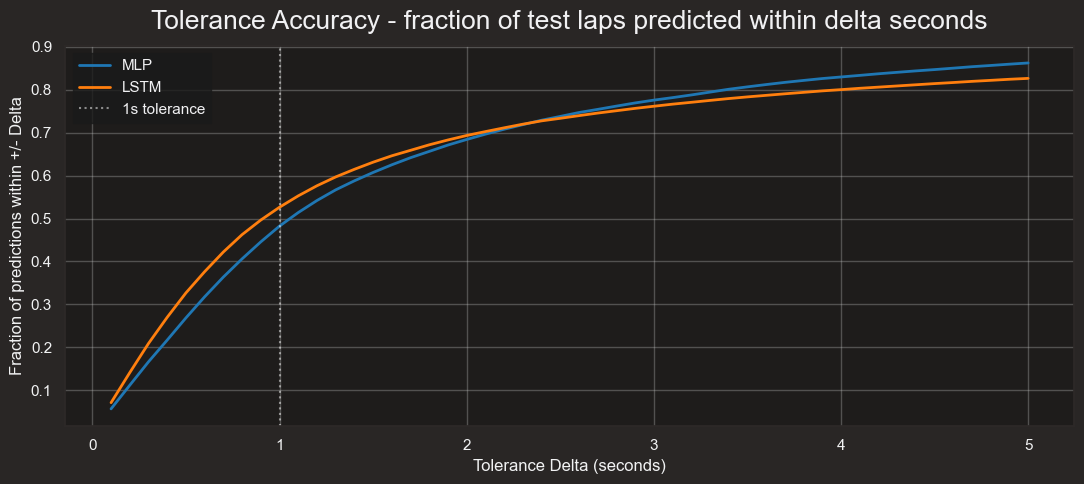

In [117]:
fig, ax = plt.subplots(figsize=(11,5))
mlp_acc, thresholds = tolerance_acc_curve(mlp, test_loader)
lstm_acc, _ = tolerance_acc_curve(lstm, test_loader)
ax.plot(thresholds, mlp_acc,  label='MLP',  color='tab:blue',   linewidth=2)
ax.plot(thresholds, lstm_acc, label='LSTM', color='tab:orange', linewidth=2)
ax.axvline(1.0, color='white', linestyle=':', alpha=0.5, label='1s tolerance')
ax.set_xlabel('Tolerance Delta (seconds)')
ax.set_ylabel('Fraction of predictions within +/- Delta')
ax.set_title('Tolerance Accuracy - fraction of test laps predicted within delta seconds')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('report/figures/tolerance_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

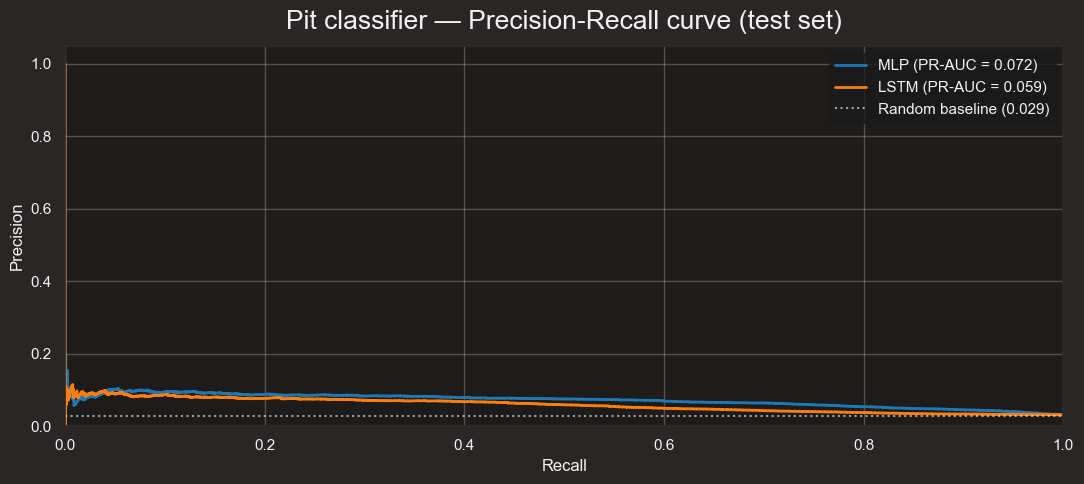

In [118]:
def get_pit_predictions(model, loader):
    '''Return (scores, labels) for the pit head over the loader.'''
    model.eval()
    scores_all, labels_all = [], []
    with torch.no_grad():
        for xb, yb_delta, yb_pit in loader:
            xb = xb.to(device)
            _, pit_logits = model(xb)
            scores_all.append(pit_logits.cpu().numpy())
            labels_all.append(yb_pit.numpy())
    return np.concatenate(scores_all).flatten(), np.concatenate(labels_all).flatten()


fig, ax = plt.subplots(figsize=(11, 5))
PIT_BASE_RATE = 0.029

for model_obj, name, color in [(mlp, 'MLP', 'tab:blue'), (lstm, 'LSTM', 'tab:orange')]:
    scores, labels = get_pit_predictions(model_obj, test_loader)
    precision, recall, _ = precision_recall_curve(labels, scores)
    pr_auc = average_precision_score(labels, scores)
    ax.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc:.3f})', color=color, linewidth=2)

ax.axhline(PIT_BASE_RATE, color='white', linestyle=':', alpha=0.6,
           label=f'Random baseline ({PIT_BASE_RATE:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Pit classifier — Precision-Recall curve (test set)')
ax.set_xlim(0, 1)
ax.set_ylim(0, max(0.5, ax.get_ylim()[1]))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('report/figures/pit_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()


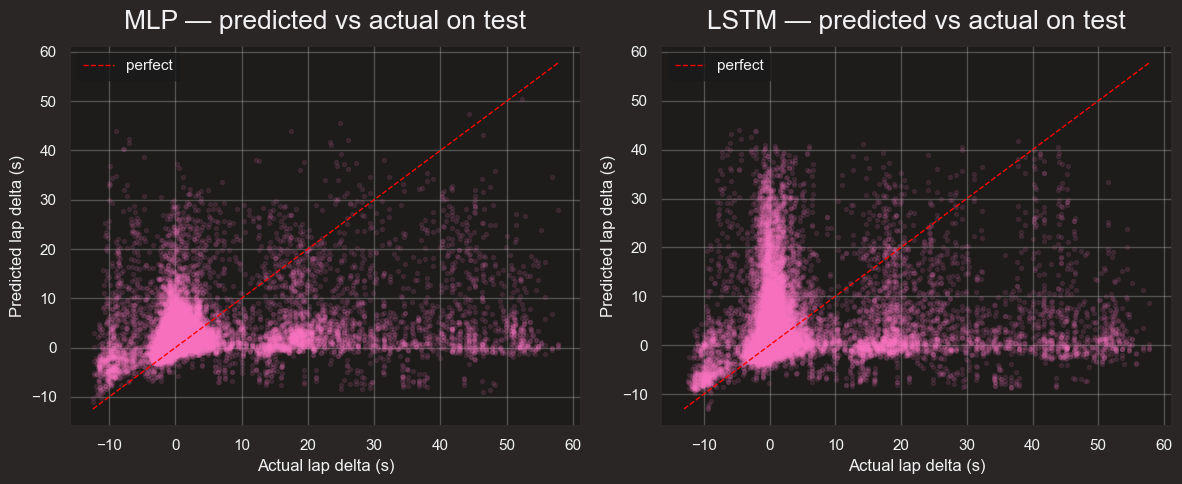

In [119]:
mlp_pred,  mlp_true  = get_predictions(mlp,  test_loader)
lstm_pred, lstm_true = get_predictions(lstm, test_loader)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, true, name in [
    (axes[0], mlp_pred,  mlp_true,  'MLP'),
    (axes[1], lstm_pred, lstm_true, 'LSTM'),
]:
    ax.scatter(true, pred, alpha=0.1, s=8)
    lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    ax.plot(lims, lims, color='red', linestyle='--', linewidth=1, label='perfect')
    ax.set_xlabel('Actual lap delta (s)')
    ax.set_ylabel('Predicted lap delta (s)')
    ax.set_title(f'{name} — predicted vs actual on test')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('report/figures/pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()